<a href="https://colab.research.google.com/github/dnhshl/cc-ai/blob/main/carpole26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modul 2: Deep Q-Learning (DQN)
### KI in der Robotik - Hochschule Hamm-Lippstadt

In diesem Notebook ersetzen wir die klassische Q-Table durch ein **Neuronales Netzwerk**.
Dies ist notwendig, da die Anzahl der Zustände für reale Probleme schnell explodieren kann.
Ein Deep Q-Network nutzt ein neuronales Netz, um die Q-Funktion $Q(s, a; \theta)$ zu repräsentieren.

**Beispiel:** CartPole (Ein Wagen versucht, einen Stab stabil zu balancieren).

DN 26.1.26

In [1]:
# 1. Installation & Imports
!pip install gymnasium[classic_control] torch numpy matplotlib

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from collections import deque
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Das neuronale Netzwerk
Der Input des Netzwerks ist der Zustand $s$.
Der Output ist der geschätzte Wert (Q-Wert) jeder Aktion für diesen Zustand.



In [2]:
# Die Netzwerk-Struktur
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.fc(x)

## 3. Kostenfunktion & Gradientenabstieg
Um das Netzwerk zu trainieren, führen wir eine Kostenfunktion $U(\theta)$ ein.
Wir minimieren $U$ mittels Gradientenabstieg.
Der Lernprozess aktualisiert die Parameter $\theta$, um den Fehler zwischen Schätzung und Realität zu verringern.

In [13]:
# 2. Der Agent mit Target-Network (Folie 42 & 43)
class DQNAgent:
    def __init__(self, state_dim, action_dim, device):
        self.device = device
        self.action_dim = action_dim

        # Policy Network: Das Netz, das wir aktiv trainieren (Folie 41)
        self.policy_net = QNetwork(state_dim, action_dim).to(device)

        # Target Network: Die stabile Referenz (Folie 42: theta_old)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval() # Wird nicht trainiert

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=1e-3)
        self.memory = deque(maxlen=10000) # Replay Buffer zur Entkorrelierung

        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.05

    def select_action(self, state):
        # Epsilon-Greedy Strategie (Folie 37)
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)

        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.policy_net(state).argmax().item()

    def train(self, batch_size=64):
        if len(self.memory) < batch_size:
            return

        # Zufälliges Sample aus dem Gedächtnis
        batch = random.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)

        # Aktuelle Vorhersage (Folie 41: Q(s, a; theta))
        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1))

        # Zielwert-Berechnung mit Target-Network (Folie 42: theta_old)
        # Target = r + gamma * max Q(s', a'; theta_old)
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1)[0]
            target_q = rewards + (1 - dones) * self.gamma * next_q

        # Kostenfunktion U (Folie 42/43)
        loss = nn.MSELoss()(current_q.squeeze(), target_q)

        # Optimierung (Folie 43: Update theta)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Epsilon reduzieren
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def soft_update_target_network(self, tau=0.005):
        """
        Gleitende Synchronisierung von theta nach theta_old (Folie 42/43).
        theta_target = tau * theta_policy + (1 - tau) * theta_target
        """
        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(tau * policy_param.data + (1.0 - tau) * target_param.data)



In [17]:
# 1. Device definieren (Nutzt GPU falls vorhanden, sonst CPU)
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Environment und Agent initialisieren
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0] # Folie 41: Input
action_dim = env.action_space.n           # Folie 41: Output

agent = DQNAgent(state_dim, action_dim, device)
scores = []

# 3. Der Loop (180 Minuten füllen: Hier passiert das Lernen)
for episode in range(200):
    state, info = env.reset()
    score = 0

    for t in range(500):
        # Aktion wählen (Folie 37)
        action = agent.select_action(state)

        # Schritt ausführen (Folie 24)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Erfahrung speichern (Replay Buffer)
        agent.memory.append((state, action, reward, next_state, done))

        # Training-Schritt (Folie 42 & 43)
        agent.train()

        agent.soft_update_target_network(tau=0.005)

        state = next_state
        score += reward

        if done:
            break


    scores.append(score)

    # PRINT AUSGABE: Alle 10 Episoden den Fortschritt anzeigen
    if episode % 10 == 0:
        # Berechne Durchschnitt der letzten 10 Episoden für stabilere Anzeige
        avg_score = np.mean(scores[-10:])
        print(f"Episode: {episode:3d} | "
              f"Score: {score:5.1f} | "
              f"Ø-Score (10 eps): {avg_score:5.1f} | "
              f"Epsilon: {agent.epsilon:.2f}")

print("Training beendet!")

Episode:   0 | Score:  83.0 | Ø-Score (10 eps):  83.0 | Epsilon: 0.90
Episode:  10 | Score:   9.0 | Ø-Score (10 eps):  13.4 | Epsilon: 0.46
Episode:  20 | Score:   9.0 | Ø-Score (10 eps):  14.4 | Epsilon: 0.22
Episode:  30 | Score:  15.0 | Ø-Score (10 eps):  17.1 | Epsilon: 0.10
Episode:  40 | Score:  23.0 | Ø-Score (10 eps):  21.3 | Epsilon: 0.05
Episode:  50 | Score:  14.0 | Ø-Score (10 eps):  24.1 | Epsilon: 0.05
Episode:  60 | Score: 177.0 | Ø-Score (10 eps): 170.4 | Epsilon: 0.05
Episode:  70 | Score: 169.0 | Ø-Score (10 eps): 190.2 | Epsilon: 0.05
Episode:  80 | Score: 184.0 | Ø-Score (10 eps): 187.5 | Epsilon: 0.05
Episode:  90 | Score: 176.0 | Ø-Score (10 eps): 176.4 | Epsilon: 0.05
Episode: 100 | Score: 154.0 | Ø-Score (10 eps): 179.0 | Epsilon: 0.05
Episode: 110 | Score: 169.0 | Ø-Score (10 eps): 179.5 | Epsilon: 0.05
Episode: 120 | Score: 196.0 | Ø-Score (10 eps): 176.9 | Epsilon: 0.05
Episode: 130 | Score: 175.0 | Ø-Score (10 eps): 178.6 | Epsilon: 0.05
Episode: 140 | Score

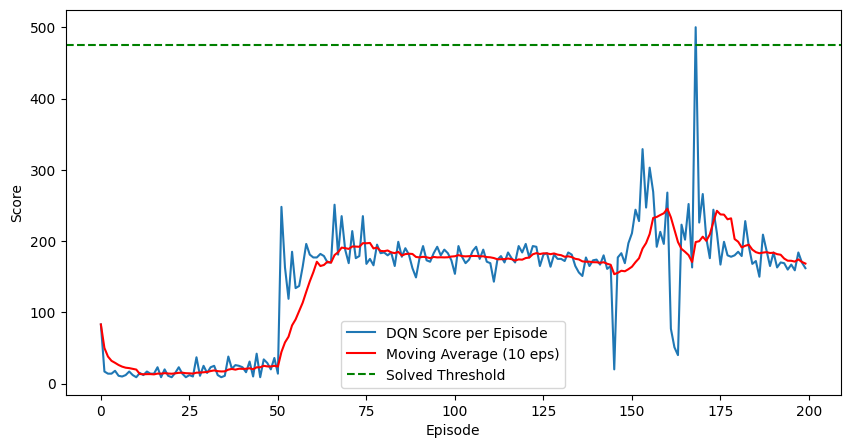

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(scores, label="DQN Score per Episode")
# Gleitender Durchschnitt zur besseren Sichtbarkeit
moving_avg = [np.mean(scores[max(0, i-10):i+1]) for i in range(len(scores))]
plt.plot(moving_avg, label="Moving Average (10 eps)", color="red")
plt.axhline(y=475, color='g', linestyle='--', label='Solved Threshold')
plt.xlabel("Episode")
plt.ylabel("Score")
plt.legend()
plt.show()

Erzeuge Visualisierung...


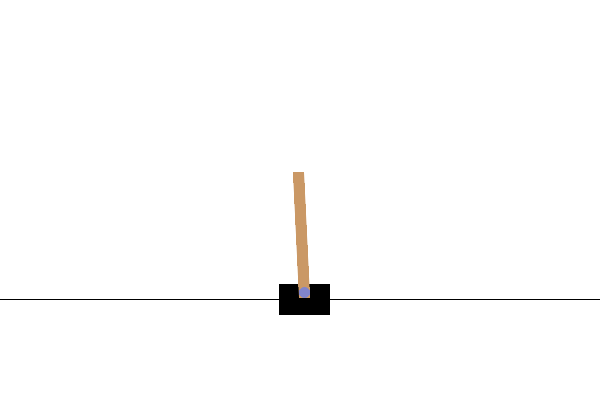

In [19]:
import imageio
from IPython.display import Image, display

# 1. Environment für grafische Ausgabe initialisieren
env_vis = gym.make("CartPole-v1", render_mode="rgb_array")
state, _ = env_vis.reset()
frames = []
done = False

print("Erzeuge Visualisierung...")

# 2. Episode durchlaufen und Frames sammeln
for t in range(500):
    # Aktuelles Bild aufnehmen
    frames.append(env_vis.render())

    # Beste Aktion wählen (Exploitation)
    with torch.no_grad():
        state_t = torch.FloatTensor(state).to(device)
        action = agent.policy_net(state_t).argmax().item()

    # Schritt ausführen
    state, reward, terminated, truncated, _ = env_vis.step(action)

    if terminated or truncated:
        break

env_vis.close()

# 3. Als GIF speichern und anzeigen
imageio.mimsave('cartpole_result.gif', frames, fps=30)
display(Image(filename='cartpole_result.gif'))